# Analyst evaluation — first version

For each persona that has a saved `run_analyst_ic` output in `reports/`, this notebook reports:

- **Numbers** — rank IC, hit ratio, t-stat, implied IR vs the breadth bar, and whether conviction adds ordering (calibration split).
- **Series** — a time-series of the up/down/flat decisions, with the realized next-release move overlaid.
- **Report diagnosis** — does the written prose agree with the numeric call (`dir_consistent`) and with what actually happened (hit rate); plus grounding / mandate checks.
- **Written recommendations** — a short per-persona read and a synthesis.

It **auto-discovers** runs (nothing hardcoded): drop a new `reports/<driver>_sonnet.jsonl` in and re-run.

> **Handoff — next phase (another agent).** TODOs are marked `# TODO(next)` below. Natural extensions: per-feature attribution (which measurement each call tracked), pre/post-COVID and post-training-cutoff leak slices, cross-persona correlation of the signed streams (the independence the design buys), and an LLM-judge pass on the reports.


In [1]:
import os, sys, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# repo root on the path (this notebook lives in notebooks/)
sys.path.insert(0, os.path.abspath(".."))
from src.layered.evaluation import ICEvaluator, required_ic, load_run, discover_runs
from src.layered.evaluation import report_quality as rq

# ── config ────────────────────────────────────────────────────────────────
REPORTS_DIR  = "../reports"
WINDOW       = ("2016-01-01", "2025-12-31")   # common evaluation window across personas
TARGET_MODEL = "claude-sonnet-5"              # the model this evaluation focuses on

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
DIR_COLOR = {"up": "#2e7d32", "down": "#c62828", "flat": "#9e9e9e"}


/Users/eliasroubache/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/eliasroubache/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 1 · Discover the runs

In [2]:
runs, catalog = {}, []
for p in discover_runs(REPORTS_DIR):
    try:
        r = load_run(p)
    except Exception as e:            # a malformed / empty file should not stop the notebook
        print("skip", p, "→", e); continue
    runs[p] = r
    catalog.append({"driver": r.driver, "model": r.model, "n": len(r.views),
                    "start": r.views.index.min().date(), "end": r.views.index.max().date(),
                    "degraded": int(r.views.degraded.sum()), "file": os.path.basename(p)})
catalog = pd.DataFrame(catalog).sort_values(["driver", "model"]).reset_index(drop=True)
catalog


,driver,model,n,start,end,degraded,file
0,balance_sheet,claude-sonnet-5,120,2016-01-31,2025-12-31,0,balance_sheet_sonnet.jsonl
1,curve_slope,claude-sonnet-5,120,2016-01-31,2025-12-31,0,curve_slope_sonnet.jsonl
2,financial_conditions,claude-sonnet-5,120,2016-01-31,2025-12-31,0,financial_conditions_sonnet.jsonl
3,inflation,claude-haiku-4-5-20251001,256,2005-01-15,2026-05-15,0,inflation_ic.jsonl
4,inflation,claude-haiku-4-5-20251001,256,2005-01-15,2026-05-15,0,inflation_ic_v2.jsonl
5,inflation,claude-haiku-4-5-20251001,256,2005-01-15,2026-05-15,1,sweep_haiku.jsonl
6,inflation,claude-haiku-4-5-20251001,256,2005-01-15,2026-05-15,1,sweep_haiku_desc.jsonl
7,inflation,claude-opus-4-8,256,2005-01-15,2026-05-15,1,sweep_opus.jsonl
8,inflation,claude-opus-4-8,256,2005-01-15,2026-05-15,0,sweep_opus_desc.jsonl
9,inflation,claude-sonnet-5,256,2005-01-15,2026-05-15,0,sweep_sonnet.jsonl


Select **one run per driver** at the target model for the evaluation (prefer a clean run — not a `*_desc` A/B variant, not the old `inflation_ic` scratch).

In [3]:
def pick_run(driver):
    cands = [r for r in runs.values() if r.driver == driver and r.model == TARGET_MODEL]
    if not cands:
        return None
    cands.sort(key=lambda r: ("desc" in r.path, "inflation_ic" in r.path, -len(r.views)))
    return cands[0]

drivers  = sorted({r.driver for r in runs.values()})
selected = {d: pick_run(d) for d in drivers}
selected = {d: r for d, r in selected.items() if r is not None}
print("evaluating:", {d: os.path.basename(r.path) for d, r in selected.items()})
missing = [d for d in drivers if d not in selected]
if missing:
    print("no", TARGET_MODEL, "run for:", missing)


evaluating: {'balance_sheet': 'balance_sheet_sonnet.jsonl', 'curve_slope': 'curve_slope_sonnet.jsonl', 'financial_conditions': 'financial_conditions_sonnet.jsonl', 'inflation': 'sweep_sonnet.jsonl', 'inflation_expectations': 'inflation_expectations_sonnet.jsonl', 'labor_tightness': 'labor_tightness_sonnet.jsonl', 'term_premium': 'term_premium_sonnet.jsonl'}


## 2 · Numbers — IC, hit ratio, calibration

In [4]:
def evaluate(run, window=WINDOW):
    s  = run.signed.loc[window[0]:window[1]]
    lv = run.level.loc[window[0]:window[1]].dropna()
    ev = ICEvaluator(lv, steps=1)
    res = ev.evaluate(s, run.driver)
    breadth = ev.breadth
    dir_ic  = ev.evaluate(np.sign(s), "dir").ic          # direction alone, no sizing
    return {
        "driver": run.driver, "n": res.n,
        "IC": res.ic, "t": res.t_stat, "hit": res.hit_rate,
        "IR": res.ic * math.sqrt(breadth) if breadth == breadth else np.nan,
        "IC_dir_only": dir_ic, "conv_adds": res.ic - dir_ic,
        "bar_IC(IR=1)": required_ic(1.0, breadth),
    }

summary = pd.DataFrame([evaluate(r) for r in selected.values()]).set_index("driver")
summary = summary.sort_values("IC", ascending=False).round(3)
summary


,n,IC,t,hit,IR,IC_dir_only,conv_adds,bar_IC(IR=1)
driver,,,,,,,,
balance_sheet,119,0.717,11.117,0.874,2.460,0.680,0.037,0.291
inflation,118,0.402,4.725,0.677,1.379,0.399,0.003,0.291
financial_conditions,119,0.234,2.601,0.605,0.803,0.167,0.067,0.291
labor_tightness,118,0.165,1.801,0.585,0.566,0.143,0.022,0.291
curve_slope,119,0.107,1.169,0.566,0.369,0.117,-0.009,0.291
term_premium,119,0.057,0.614,0.471,0.195,-0.009,0.065,0.291
inflation_expectations,119,-0.099,-1.081,0.388,-0.341,-0.127,0.027,0.291


**Reading it.** `IC` is rank correlation of the signed conviction with the next-release move; `hit` is directional accuracy on non-flat calls. `IR = IC·√breadth` with breadth ≈ one bet per release (~12/yr), and `bar_IC(IR=1)` is the IC a single driver would need for an information ratio of 1. `conv_adds` is `IC(signed) − IC(direction only)`: positive means conviction carries ordering information beyond the up/down call. At ~110 obs, only |IC| ≳ 0.29 clears t > 2 — **read the t-stat, not the third decimal.**

## 3 · Series — the up/down decisions over time

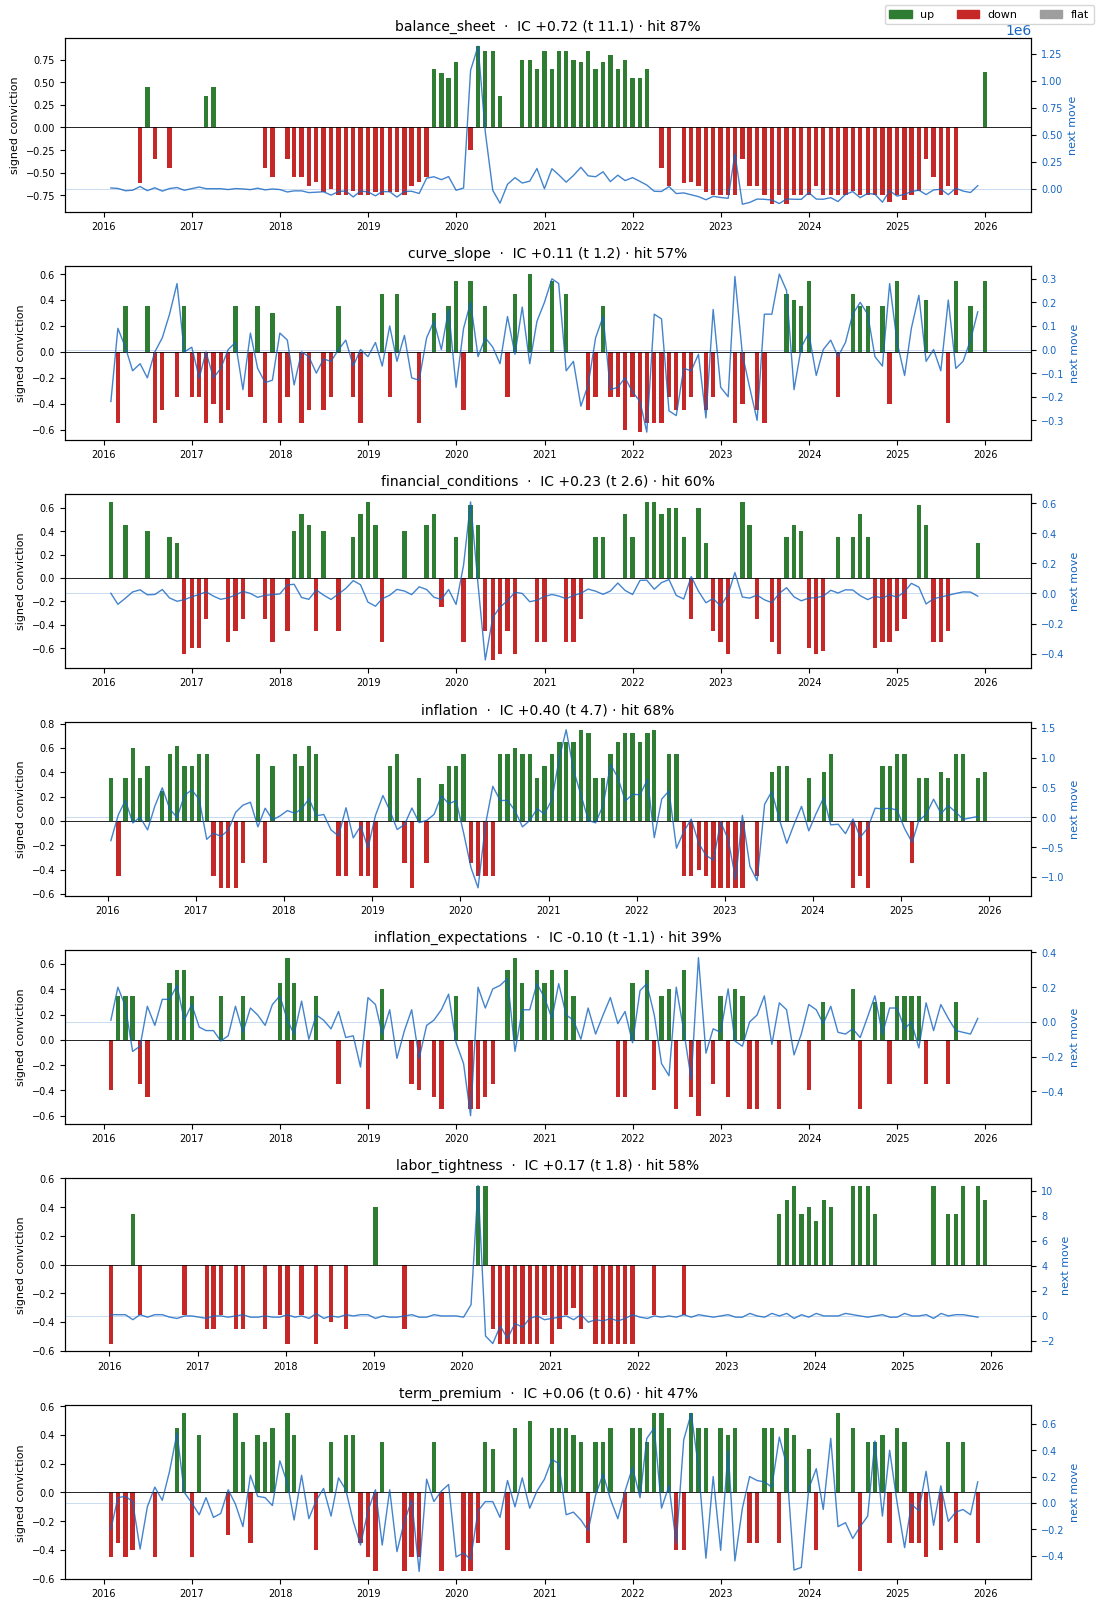

In [5]:
def plot_decisions(run, ax, window=WINDOW):
    df = run.views.loc[window[0]:window[1]]
    s  = df["signed"]
    colors = df["direction"].map(DIR_COLOR)
    ax.bar(s.index, s.values, width=18, color=colors, align="center")
    ax.axhline(0, color="k", lw=0.6)
    # realized next-release move (right axis) — did the driver actually go the called way?
    lv = run.level.loc[window[0]:window[1]].dropna()
    outcome = (lv.shift(-1) - lv).reindex(df.index)
    ax2 = ax.twinx()
    ax2.plot(outcome.index, outcome.values, color="#1565c0", lw=1.0, alpha=0.8)
    ax2.axhline(0, color="#1565c0", lw=0.4, alpha=0.4)
    ax2.set_ylabel("next move", color="#1565c0", fontsize=8)
    ax2.tick_params(axis="y", labelcolor="#1565c0", labelsize=7)
    m = summary.loc[run.driver]
    ax.set_title(f"{run.driver}  ·  IC {m.IC:+.2f} (t {m.t:.1f}) · hit {m.hit:.0%}", fontsize=10)
    ax.set_ylabel("signed conviction", fontsize=8)
    ax.tick_params(labelsize=7)

n = len(selected)
fig, axes = plt.subplots(n, 1, figsize=(11, 2.3 * n), squeeze=False)
for ax, run in zip(axes[:, 0], selected.values()):
    plot_decisions(run, ax)
from matplotlib.patches import Patch
fig.legend(handles=[Patch(color=DIR_COLOR[k], label=k) for k in ("up", "down", "flat")],
           loc="upper right", ncol=3, fontsize=8)
fig.tight_layout()
plt.show()


Green/red/grey bars are the analyst's signed conviction (up / down / flat); the blue line is the **realized** next-release move. Where a green bar sits over a rising blue line (or red over falling), the call was right.

## 4 · Report diagnosis — does the prose match the numbers?

In [6]:
qrows = []
for d, r in selected.items():
    q = rq.evaluate_run(r.path, driver=d)     # deterministic lexical checks over the prose
    q["driver"] = d
    qrows.append(q)
quality = pd.DataFrame(qrows).set_index("driver")
quality = quality[["n", "dir_consistent", "names_trade", "hallucinated",
                   "cites_text", "cross_driver", "has_falsifier", "med_words"]]
quality


,n,dir_consistent,names_trade,hallucinated,cites_text,cross_driver,has_falsifier,med_words
driver,,,,,,,,
balance_sheet,120,0.958,0.000,0.017,0.300,0.858,1.0,190
curve_slope,120,0.717,1.000,0.017,0.292,0.975,1.0,195
financial_conditions,120,0.908,0.025,0.025,0.192,0.433,1.0,195
inflation,256,0.879,0.000,0.004,0.180,0.688,1.0,205
inflation_expectations,120,0.950,0.000,0.017,0.450,1.000,1.0,193
labor_tightness,119,0.958,0.000,0.008,0.134,0.899,1.0,202
term_premium,120,0.908,0.000,0.025,0.258,1.000,1.0,197


`dir_consistent` is the alignment the question asks for: the fraction of reports whose **prose leans the same way as the numeric direction**. `names_trade` should be ~0 (the mandate forbids naming a trade), `hallucinated` ~0 (evidence cited must be a real feature name), `has_falsifier` ~1. `cross_driver` is a soft lexical flag for drifting onto another driver's vocabulary. *(Report-quality is computed over each run's full file; the numbers above are over the common window.)*

In [7]:
# Two senses of "aligned": prose-vs-header, and header-vs-outcome (was it actually right?)
alignment = pd.DataFrame({
    "prose_vs_header": quality["dir_consistent"],
    "header_vs_outcome (hit)": summary["hit"],
}).round(3)
alignment


,prose_vs_header,header_vs_outcome (hit)
driver,,
balance_sheet,0.958,0.874
curve_slope,0.717,0.566
financial_conditions,0.908,0.605
inflation,0.879,0.677
inflation_expectations,0.950,0.388
labor_tightness,0.958,0.585
term_premium,0.908,0.471


## 5 · Written recommendations

In [8]:
def verdict(m):
    if m["t"] >= 2 and m["IC"] > 0:      return "real, significant skill"
    if m["IC"] >= 0.10:                  return "positive but not significant at this sample"
    if m["IC"] <= -0.10:                 return "negative — calls anti-correlated with outcomes"
    return "no measurable skill"

for d in summary.index:
    m, q = summary.loc[d], quality.loc[d]
    print(f"### {d}")
    print(f"  IC {m.IC:+.3f} (t {m.t:+.1f}), hit {m.hit:.0%}, implied IR {m.IR:+.2f} "
          f"(bar for IR 1.0 is IC {m['bar_IC(IR=1)']:.2f}) → {verdict(m)}.")
    conv = ("adds ordering info (+%.3f)" % m.conv_adds) if m.conv_adds > 0.02 else "adds ~nothing"
    print(f"  conviction {conv}; prose agrees with the call {q.dir_consistent:.0%} of the time, "
          f"falsifier present {q.has_falsifier:.0%}, ~{int(q.med_words)} words.")
    flags = []
    if q.names_trade > 0.02:  flags.append(f"names a trade {q.names_trade:.0%}")
    if q.hallucinated > 0.02: flags.append(f"hallucinated evidence {q.hallucinated:.0%}")
    if flags: print("  flags:", "; ".join(flags))
    print()


### balance_sheet
  IC +0.717 (t +11.1), hit 87%, implied IR +2.46 (bar for IR 1.0 is IC 0.29) → real, significant skill.
  conviction adds ordering info (+0.037); prose agrees with the call 96% of the time, falsifier present 100%, ~190 words.

### inflation
  IC +0.402 (t +4.7), hit 68%, implied IR +1.38 (bar for IR 1.0 is IC 0.29) → real, significant skill.
  conviction adds ~nothing; prose agrees with the call 88% of the time, falsifier present 100%, ~205 words.

### financial_conditions
  IC +0.234 (t +2.6), hit 60%, implied IR +0.80 (bar for IR 1.0 is IC 0.29) → real, significant skill.
  conviction adds ordering info (+0.067); prose agrees with the call 91% of the time, falsifier present 100%, ~195 words.
  flags: names a trade 2%; hallucinated evidence 2%

### labor_tightness
  IC +0.165 (t +1.8), hit 58%, implied IR +0.57 (bar for IR 1.0 is IC 0.29) → positive but not significant at this sample.
  conviction adds ordering info (+0.022); prose agrees with the call 96% of the tim

### Synthesis & next steps

*(Auto-generated numbers above; narrative to be written once all seven personas have runs.)*

- **Skill** varies by driver — read the per-persona verdicts and the IC/t column. Inflation is the reference (it also has Haiku/Opus runs for a model-strength read via `compare_sweep`).
- **Calibration** — where `conv_adds` ≈ 0, the conviction ladder is not buying ordering beyond direction; sizing has headroom.
- **Reports are well-formed** where `names_trade`/`hallucinated` ≈ 0 and `has_falsifier` ≈ 1; `dir_consistent` is the prose↔number agreement.

**`# TODO(next)` for the next agent:**
1. Per-feature attribution — correlate each persona's signed conviction with its own features (`FeaturePanel`) to see *which* measurement it tracked, and whether that one is stable out-of-sample.
2. Leak / OOS slices — pre-COVID vs COVID+ vs post-training-cutoff (2025+), reusing the split in `compare_sweep`.
3. Cross-persona correlation — pairwise corr of the signed streams on a common calendar (the independence the layered design is buying).
4. LLM-judge pass on the reports (beyond the lexical checks here).
